---
title: "Volatility Forecasts (Part 5 — PGARCH: Structure-Aware Variance Forecasting)"
date: 2026-03-10
description: "GARCH(1,1) outperformed flexible gate models under QLIKE because it separates level, persistence, and innovation share. We introduce PGARCH — a predictor-driven GARCH decomposition — and benchmark Linear PGARCH and XGB-g-PGARCH against the seven models from Part 4."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
content-type: "series"
series-id: "volatility-forecasting"
series-title: "Volatility Forecasts"
series-part: 5
project-ids: [volatility-forecasting]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---

## Introduction

In [Part 4](../volatility-forecasts-4/) we ran a training experiment: each model family — ES, STES, and XGBSTES — was fitted under both RMSE and QLIKE, then scored on both metrics out of sample. The most striking result was that the **GARCH(1,1)** model consistently ranked first in out-of-sample QLIKE while placing a competitive third in RMSE — despite using no predictor features at all.

At first glance this is puzzling. STES and XGBSTES are more flexible: they allow the smoothing weight to vary with predictors and, in the case of XGBSTES, through a nonlinear boosted mapping. One would expect this flexibility to help, or at least not hurt, once all models are trained on the same objective. Yet GARCH consistently won under QLIKE.

One explanation lies in what GARCH separates and what STES-type models entangle. A standard GARCH(1,1) recursion,

$$
h_t = \omega + \alpha y_{t-1} + \beta h_{t-1}
$$

can be rewritten by defining $\phi = \alpha + \beta$, $g = \alpha/(\alpha+\beta)$, and $\mu = \omega/(1-\alpha-\beta)$ as

$$
h_t = (1-\phi)\mu + \phi\Big(g y_{t-1} + (1-g) h_{t-1}\Big)
$$

This decomposition contains three distinct structures:

- $\mu$: the **long-run variance anchor** — the level the forecast reverts to,
- $\phi$: the **total persistence** — how much weight goes to recent information versus the anchor,
- $g$: the **innovation share** — within the persistent component, how much weight goes to yesterday's shock versus yesterday's state.

A STES-style recursion $h_t = g_t y_{t-1} + (1-g_t) h_{t-1}$ varies only the innovation share. It does not separately estimate a long-run anchor or a total persistence parameter. A single gate must simultaneously decide how much to react to the latest shock, how much memory to retain, and what level the recursion drifts toward. That is too much to ask from one scalar mechanism — especially under QLIKE.

QLIKE penalizes proportionally: driving $h_t$ too low is punished much more heavily than overshooting by the same absolute amount. This makes the loss especially sensitive to getting the **variance scale** and **persistence structure** right. GARCH's intercept $\omega$, equivalently the anchor $\mu$, prevents the forecast from collapsing toward zero — exactly the failure mode that QLIKE punishes most. STES has no such safeguard.

This motivates a new model family: **Predictive GARCH (PGARCH)**. The idea is to keep the GARCH-like structural decomposition that appears essential for QLIKE performance, but let the structural components be predictor-driven and time-varying. Instead of predicting $(\omega_t, \alpha_t, \beta_t)$ directly, we parameterize through the interpretable triple $(\mu_t, \phi_t, g_t)$ and define

$$
h_t = (1-\phi_t)\mu_t + \phi_t\Big(g_t y_{t-1} + (1-g_t) h_{t-1}\Big)
$$

We introduce two first members of this family:

1. **PGARCH-L** (Linear PGARCH): all three channels are linear functions of predictors, trained end-to-end by L-BFGS-B with analytic recursive gradients.
2. **XGB-g-PGARCH**: $\mu$ and $\phi$ come from a fitted PGARCH-L initializer; the innovation-share channel $g$ is then refined by a gradient-boosted tree with a custom adjoint-based objective.

The rest of this post defines the model family, derives the key equations, and benchmarks both variants against the seven models from Part 4 on the same SPY sample and fixed split.

In [1]:
#| echo: false
#| output: false

import sys
import os
import logging
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler

# --- PATH SETUP ---
def _find_workspace_root(start: Path) -> Path:
    required = ("steveya.github.io", "volatility-forecast", "alphaforge")
    for candidate in (start, *start.parents):
        if all((candidate / name).exists() for name in required):
            return candidate
    raise RuntimeError(
        f"Could not locate workspace root from {start}. Expected sibling repos: {required}"
    )


WORKSPACE_ROOT = _find_workspace_root(Path.cwd().resolve())
BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / ".env")
logging.basicConfig(level=logging.ERROR)

# --- LIBRARY IMPORTS ---
from alphaforge.data.cache import FileCacheBackend
from alphaforge.data.query import Query
from volatility_forecast.pipeline import build_default_ctx, build_vol_dataset, VolDatasetSpec
from volatility_forecast.sources import TiingoEODSource
from volatility_forecast.evaluation.metrics import rmse, mae, qlike
from volatility_forecast.evaluation.dm_test import diebold_mariano
from volatility_forecast.evaluation.mz import mincer_zarnowitz

from volatility_forecast.model.pgarch_linear_model import PGARCHLinearModel
from volatility_forecast.model.xgb_pgarch_model import XGBGPGARCHModel

import volatility_forecast.model.stes_model as stes_module
import volatility_forecast.model.tree_stes_model as tree_stes_module
importlib.reload(stes_module)
importlib.reload(tree_stes_module)
STESModel = stes_module.STESModel
XGBoostSTESModel = tree_stes_module.XGBoostSTESModel

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style, BLOG_PALETTE,
)

# --- CACHE ---
SCRIPT_CACHE_DIR = VF_PATH / ".af_cache"
SCRIPT_CACHE_MODE = "use"

# --- STYLES ---
inject_blog_table_css()
apply_blog_plot_style()

# --- DATA CONTEXT ---
cache = FileCacheBackend(SCRIPT_CACHE_DIR)
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode=SCRIPT_CACHE_MODE,
)
print(f"Tiingo cache dir: {SCRIPT_CACHE_DIR}")
print(f"Tiingo cache mode: {SCRIPT_CACHE_MODE}")

Tiingo cache dir: /Users/steveyang/Projects/steveya/volatility-forecast/.af_cache
Tiingo cache mode: use


In [2]:
#| echo: false
#| output: false

from arch import arch_model
from alphaforge.features.dataset_spec import (
    UniverseSpec, TimeSpec, FeatureRequest, TargetRequest, JoinPolicy, MissingnessPolicy,
)
from volatility_forecast.features.return_features import (
    LagLogReturnTemplate, LagAbsLogReturnTemplate, LagSquaredLogReturnTemplate,
)
from volatility_forecast.targets.squared_return import NextDaySquaredReturnTarget

# --- SAMPLE PARAMETERS (identical to Part 4) ---
SAMPLE_TICKER = "SPY"
SAMPLE_START = pd.Timestamp("2000-01-01", tz="UTC")
SAMPLE_END = pd.Timestamp("2023-12-31", tz="UTC")
SAMPLE_TRAIN_START = 200
SAMPLE_SPLIT_INDEX = 4000
SCALE_FACTOR = 100.0

# --- CACHE PREFLIGHT ---
sample_cache_key = f"{SAMPLE_TICKER}|adj=True"
sample_cached = cache.get(sample_cache_key)
if sample_cached is None or sample_cached.empty:
    raise RuntimeError(f"Cache-only mode: no cached data for key={sample_cache_key}.")


# --- BUILD DATASET (same spec as Part 4) ---
def _build_spec(source, ticker, start, end, lags=0):
    return VolDatasetSpec(
        universe=UniverseSpec(entities=[ticker]),
        time=TimeSpec(start=start, end=end, calendar="XNYS", grid="B", asof=None),
        features=(
            FeatureRequest(
                template=LagLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
            FeatureRequest(
                template=LagAbsLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
            FeatureRequest(
                template=LagSquaredLogReturnTemplate(),
                params={"lags": lags, "source": source, "table": "market.ohlcv", "price_col": "close"},
            ),
        ),
        target=TargetRequest(
            template=NextDaySquaredReturnTarget(),
            params={"source": source, "table": "market.ohlcv", "price_col": "close", "scale": 1.0},
            horizon=1,
            name="y",
        ),
        join_policy=JoinPolicy(how="inner", sort_index=True),
        missingness=MissingnessPolicy(final_row_policy="drop_if_any_nan"),
    )


ctx_sample = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)
X_raw, y_raw, r_raw, _ = build_vol_dataset(ctx_sample, _build_spec("tiingo", SAMPLE_TICKER, SAMPLE_START, SAMPLE_END), persist=False)

if isinstance(X_raw.index, pd.MultiIndex):
    X_par = X_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    y_par = y_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
    r_par = r_raw.xs(SAMPLE_TICKER, level="entity_id").sort_index().astype(float)
else:
    X_par = X_raw.sort_index().astype(float)
    y_par = y_raw.sort_index().astype(float)
    r_par = r_raw.sort_index().astype(float)

if "const" not in X_par.columns:
    X_par["const"] = 1.0

common_idx = X_par.index.intersection(y_par.index).intersection(r_par.index)
X_par, y_par, r_par = X_par.loc[common_idx], y_par.loc[common_idx], r_par.loc[common_idx]

# --- FIXED SPLIT ---
X_tr = X_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
X_te = X_par.iloc[SAMPLE_SPLIT_INDEX:]
y_tr = y_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
y_te = y_par.iloc[SAMPLE_SPLIT_INDEX:]
r_tr = r_par.iloc[SAMPLE_TRAIN_START:SAMPLE_SPLIT_INDEX]
r_te = r_par.iloc[SAMPLE_SPLIT_INDEX:]

# Scaled features for STES/XGBSTES (matches Part 4)
scaler = StandardScaler()
cols_to_scale = [c for c in X_tr.columns if c != "const"]
X_tr_s, X_te_s = X_tr.copy(), X_te.copy()
if cols_to_scale:
    X_tr_s[cols_to_scale] = scaler.fit_transform(X_tr[cols_to_scale])
    X_te_s[cols_to_scale] = scaler.transform(X_te[cols_to_scale])
X_all_s = pd.concat([X_tr_s, X_te_s])
r_all = pd.concat([r_tr, r_te])
y_all = pd.concat([y_tr, y_te])

# Feature matrix for PGARCH (no const — model adds its own intercept)
pgarch_feat_cols = [c for c in X_par.columns if c != "const"]
X_pgarch_tr = X_tr[pgarch_feat_cols]
X_pgarch_te = X_te[pgarch_feat_cols]
X_pgarch_all = pd.concat([X_pgarch_tr, X_pgarch_te])

print(f"Train rows: {len(X_tr)} ({X_tr.index.min().date()} → {X_tr.index.max().date()})")
print(f"Test rows:  {len(X_te)} ({X_te.index.min().date()} → {X_te.index.max().date()})")
print(f"PGARCH features: {pgarch_feat_cols}")

Train rows: 3800 (2000-10-18 → 2015-11-25)
Test rows:  2035 (2015-11-27 → 2023-12-28)
PGARCH features: ['lag.logret.fc5d3612d9c7', 'lag.abslogret.1ad490bcb584', 'lag.sqlogret.c2cf3aa70c10']


## The PGARCH Model

### Recursion

Let $y_t \ge 0$ denote a nonnegative volatility target (we use $y_t = r_t^2$). PGARCH defines the variance forecast by

$$
h_t = (1-\phi_t)\,\mu_t + \phi_t\,q_t, \qquad q_t = g_t\,y_{t-1} + (1-g_t)\,h_{t-1},
$$

with constraints $\mu_t > 0$, $\phi_t \in (0,1)$, $g_t \in (0,1)$, and a fixed initial state $h_0 \ge 0$.

The quantity $q_t$ is a convex combination of yesterday's shock $y_{t-1}$ and yesterday's state $h_{t-1}$. The full forecast $h_t$ is then a convex combination of the long-run anchor $\mu_t$ and $q_t$, weighted by persistence $\phi_t$.

### Implied GARCH representation

Defining $\omega_t = (1-\phi_t)\mu_t$, $\alpha_t = \phi_t g_t$, $\beta_t = \phi_t(1-g_t)$, the recursion becomes

$$
h_t = \omega_t + \alpha_t\,y_{t-1} + \beta_t\,h_{t-1},
$$

a time-varying GARCH(1,1) with $\alpha_t + \beta_t = \phi_t < 1$ enforced by construction.

### Special cases

| Restriction | Model recovered |
|---|---|
| $\mu_t = \mu$, $\phi_t = \phi$, $g_t = g$ constant | Constrained GARCH(1,1) |
| $\phi_t \equiv 1$, anchor dropped | STES exponential smoothing |
| $(\mu_t, \phi_t, g_t)$ are linear functions of predictors | **PGARCH-L** (this post) |
| $g_t$ boosted by XGBoost, $\mu_t$ and $\phi_t$ from PGARCH-L | **XGB-g-PGARCH** (this post) |

The nesting structure is the key insight: PGARCH does not abandon GARCH's recursion. It generalizes the *parameter mapping* while preserving the structural decomposition that QLIKE rewards.

## Linear PGARCH (PGARCH-L)

In PGARCH-L, each structural parameter is a linear function of predictors passed through a link that enforces its constraint. Let $\tilde{x}_{t-1} = [1, x_{t-1}]$ denote the augmented feature vector available at time $t-1$. Three linear scores

$$
a_t = w_\mu^\top \tilde{x}_{t-1}, \qquad b_t = w_\phi^\top \tilde{x}_{t-1}, \qquad c_t = w_g^\top \tilde{x}_{t-1}
$$

are mapped to the structural parameters via

$$
\mu_t = \mu_{\min} + \operatorname{softplus}(a_t), \qquad
\phi_t = \phi_{\min} + (\phi_{\max} - \phi_{\min})\, \sigma(b_t), \qquad
g_t = g_{\min} + (g_{\max} - g_{\min})\, \sigma(c_t)
$$

The softplus link guarantees $\mu_t > \mu_{\min} > 0$; the sigmoid links map $\phi_t$ and $g_t$ into $(0,1)$.

### Estimation

The full parameter vector $\theta = [w_\mu, w_\phi, w_g]$ is trained end-to-end by minimizing MSE or QLIKE over the recursive variance path. The gradient is computed analytically via a forward recursion that propagates Jacobians $J_t = \partial h_t / \partial \theta$ through the PGARCH state equations. We also derive the corresponding Hessian recursion $H_t = \partial^2 h_t / \partial \theta \partial \theta^\top$ for verification and analysis, but the implemented optimizer uses L-BFGS-B with analytic gradients rather than a supplied exact Hessian.

Because the recursion is sequential, $h_0$ is treated as a fixed causal warm start (set to $\max(y_0, h_{\min})$), and the loss is computed only over $t = 1, \ldots, T-1$. Full derivative formulas appear in the [Appendix](#appendix-pgarch-derivative-details).

## XGB-g-PGARCH

A full nonlinear PGARCH could let all three channels be learned by flexible models. The first extension is to boost only the **innovation-share channel** $g_t$, while keeping $\mu_t$ and $\phi_t$ fixed from a PGARCH-L initializer. This targets exactly the mechanism analogous to the STES gate within the GARCH structure.

### Model structure

Given baseline sequences $\mu_t$ and $\phi_t$ from a fitted PGARCH-L, define

$$
c_t = c_t^{(0)} + F_g(x_t), \qquad g_t = g_{\min} + (g_{\max} - g_{\min})\,\sigma(c_t)
$$

where $c_t^{(0)}$ is the baseline raw score and $F_g$ is a gradient-boosted tree ensemble. The recursion remains $h_{t+1} = (1-\phi_t)\mu_t + \phi_t(g_t y_t + (1-g_t)h_t)$.

### Custom XGBoost objective

Under this indexing, row $t$ produces a raw score that affects the next-step forecast $h_{t+1}$. The exact row-wise gradient is computed via a backward adjoint recursion like we did in [Part 3](../volatility-forecasts-3/): define $\lambda_t = \partial L / \partial h_t$ (total derivative including all downstream effects), then

$$
\lambda_{T-1} = u_{T-1}, \qquad \lambda_t = u_t + \rho_t \lambda_{t+1}
$$

where $u_t = \partial \ell_t / \partial h_t$ is the per-step loss derivative and $\rho_t = \phi_t(1-g_t)$ is the state propagation coefficient. The row-wise gradient is then

$$
G_s = \lambda_{s+1} \cdot \phi_s(y_s - h_s) \cdot C_s
$$

where $C_s = (g_{\max} - g_{\min})\sigma(c_s)(1-\sigma(c_s))$ is the link derivative.

For the per-row Hessian diagonal, we use a positive curvature surrogate rather than the exact (possibly indefinite) second derivative. Under MSE this is a Gauss-Newton approximation; under QLIKE we use Fisher-style scaling $w_t = 1/(Nh_t^2)$, which is the expected information and avoids amplification from extreme observations. The terminal row ($s = T-1$) receives zero gradient and Hessian since it has no in-sample next-step forecast.

In [3]:
#| code-fold: true
#| code-summary: "Fit Part 4 baselines locally: GARCH(1,1) + ES/STES/XGBSTES under RMSE and QLIKE"

# ── GARCH(1,1) ──────────────────────────────────────────────────────────
r_tr_pct = r_tr * SCALE_FACTOR
r_all_concat = pd.concat([r_tr, r_te])
r_all_pct = r_all_concat * SCALE_FACTOR

garch_spec = arch_model(r_tr_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit = garch_spec.fit(disp="off")
omega_g, alpha_g, beta_g = garch_fit.params["omega"], garch_fit.params["alpha[1]"], garch_fit.params["beta[1]"]

cv_sq_is = garch_fit.conditional_volatility.values ** 2
r_sq_is = r_tr_pct.values ** 2
garch_pred_is = (omega_g + alpha_g * r_sq_is + beta_g * cv_sq_is) / (SCALE_FACTOR ** 2)

garch_spec_full = arch_model(r_all_pct, vol="GARCH", p=1, q=1, mean="Zero", rescale=False)
garch_fit_full = garch_spec_full.fit(disp="off", last_obs=len(r_tr))
garch_fcast = garch_fit_full.forecast(start=len(r_tr), reindex=False)
garch_pred_os = garch_fcast.variance.values.flatten() / (SCALE_FACTOR ** 2)

print(f"GARCH(1,1):  omega={omega_g:.6f}, alpha={alpha_g:.4f}, beta={beta_g:.4f}")

# ── Shared scaling and grids for STES / XGBSTES ─────────────────────────
r_tr_scaled = r_tr * SCALE_FACTOR
y_tr_scaled = y_tr * (SCALE_FACTOR ** 2)
r_all_scaled = r_all * SCALE_FACTOR

XGB_PARAMS = {
    "booster": "gblinear", "updater": "coord_descent", "max_depth": 5,
    "learning_rate": 0.01, "subsample": 1.0, "colsample_bytree": 1.0,
    "min_child_weight": 1.0, "reg_lambda": 1.0, "reg_alpha": 0.0, "verbosity": 0,
}
STES_L2_GRID = [{"l2_reg": v} for v in [0.0, 0.001, 0.01, 0.1, 1.0]]
GRID_E2E = [
    {"min_child_weight": 5.0, "learning_rate": 0.05, "max_depth": 3},
    {"min_child_weight": 20.0, "learning_rate": 0.1, "max_depth": 3},
    {"min_child_weight": 50.0, "learning_rate": 0.05, "max_depth": 2},
]

# ── ES (RMSE / QLIKE) ───────────────────────────────────────────────────
es_rmse_m = STESModel(loss="mse", random_state=42)
es_rmse_m.fit(X_tr_s[["const"]], y_tr, returns=r_tr)
_tmp, _ = es_rmse_m.predict_with_alpha(X_all_s[["const"]], returns=r_all)
es_pred_is, es_pred_os = _tmp[:len(X_tr_s)], _tmp[len(X_tr_s):]

es_qlike_m = STESModel(loss="qlike", random_state=42)
es_qlike_m.fit(X_tr_s[["const"]], y_tr, returns=r_tr)
_tmp, _ = es_qlike_m.predict_with_alpha(X_all_s[["const"]], returns=r_all)
es_qlike_pred_is, es_qlike_pred_os = _tmp[:len(X_tr_s)], _tmp[len(X_tr_s):]

# ── STES (RMSE / QLIKE) ─────────────────────────────────────────────────
stes_rmse_m = STESModel(loss="mse", random_state=42)
stes_rmse_m.fit(X_tr_s, y_tr, returns=r_tr, perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3)
_tmp, _ = stes_rmse_m.predict_with_alpha(X_all_s, returns=r_all)
stes_pred_is, stes_pred_os = _tmp[:len(X_tr_s)], _tmp[len(X_tr_s):]

stes_qlike_m = STESModel(loss="qlike", random_state=42)
stes_qlike_m.fit(X_tr_s, y_tr, returns=r_tr, perform_cv=True, cv_grid=STES_L2_GRID, cv_splits=3)
_tmp, _ = stes_qlike_m.predict_with_alpha(X_all_s, returns=r_all)
stes_qlike_pred_is, stes_qlike_pred_os = _tmp[:len(X_tr_s)], _tmp[len(X_tr_s):]

# ── XGBSTES (RMSE / QLIKE) ──────────────────────────────────────────────
xgb_rmse_m = XGBoostSTESModel(
    xgb_params=XGB_PARAMS,
    num_boost_round=200,
    fit_method="end_to_end",
    loss="mse",
    e2e_grad_hess_scale=1.0,
    random_state=42,
)
xgb_rmse_m.fit(X_tr_s, y_tr_scaled, returns=r_tr_scaled, perform_cv=True, cv_grid=GRID_E2E, cv_splits=3)
_tmp = xgb_rmse_m.predict(X_all_s, returns=r_all_scaled) / (SCALE_FACTOR ** 2)
xgbstes_pred_is, xgbstes_pred_os = _tmp[:len(X_tr_s)], _tmp[len(X_tr_s):]

xgb_qlike_m = XGBoostSTESModel(
    xgb_params=XGB_PARAMS, num_boost_round=200, fit_method="end_to_end",
    loss="qlike", e2e_grad_hess_scale=1.0, random_state=42,
)
xgb_qlike_m.fit(X_tr_s, y_tr_scaled, returns=r_tr_scaled, perform_cv=True, cv_grid=GRID_E2E, cv_splits=3)
_tmp = xgb_qlike_m.predict(X_all_s, returns=r_all_scaled) / (SCALE_FACTOR ** 2)
xgb_qlike_pred_is, xgb_qlike_pred_os = _tmp[:len(X_tr_s)], _tmp[len(X_tr_s):]

print("Part 4 baselines ready (7 models).")


GARCH(1,1):  omega=0.018841, alpha=0.0952, beta=0.8899


Part 4 baselines ready (7 models).


In [4]:
#| code-fold: true
#| code-summary: "Fit PGARCH-L and XGB-g-PGARCH under RMSE and QLIKE"

# ── PGARCH-L (RMSE) ────────────────────────────────────────────────────
pgarch_l_rmse = PGARCHLinearModel(loss="rmse", random_state=42)
pgarch_l_rmse.fit(y_tr.values, X_pgarch_tr.values)
h_pgarch_l_rmse = pgarch_l_rmse.predict_variance(y_all.values, X_pgarch_all.values)
pgarch_l_rmse_is = h_pgarch_l_rmse[:len(y_tr)]
pgarch_l_rmse_os = h_pgarch_l_rmse[len(y_tr):]

implied_rmse = pgarch_l_rmse.implied_garch_params(X_pgarch_tr.values)
print(f"PGARCH-L (RMSE) implied GARCH (mean): "
      f"omega={np.mean(implied_rmse['omega']):.6f}, "
      f"alpha={np.mean(implied_rmse['alpha']):.4f}, "
      f"beta={np.mean(implied_rmse['beta']):.4f}")

# ── PGARCH-L (QLIKE) ───────────────────────────────────────────────────
pgarch_l_qlike = PGARCHLinearModel(loss="qlike", random_state=42)
pgarch_l_qlike.fit(y_tr.values, X_pgarch_tr.values)
h_pgarch_l_qlike = pgarch_l_qlike.predict_variance(y_all.values, X_pgarch_all.values)
pgarch_l_qlike_is = h_pgarch_l_qlike[:len(y_tr)]
pgarch_l_qlike_os = h_pgarch_l_qlike[len(y_tr):]

implied_qlike = pgarch_l_qlike.implied_garch_params(X_pgarch_tr.values)
print(f"PGARCH-L (QLIKE) implied GARCH (mean): "
      f"omega={np.mean(implied_qlike['omega']):.6f}, "
      f"alpha={np.mean(implied_qlike['alpha']):.4f}, "
      f"beta={np.mean(implied_qlike['beta']):.4f}")

# ── XGB-g-PGARCH ───────────────────────────────────────────────────────
# Scale y for XGBoost to avoid the gradient suppression problem from Part 3:
# with unscaled y ~ 1e-4, the custom-objective row gradients are O(1e-5),
# completely overwhelmed by reg_lambda=1.0.  Scaling y by SCALE_FACTOR^2
# brings gradients to O(1) so that XGBoost's regularization operates on
# the correct scale.
y_tr_pgarch_scaled = y_tr.values * (SCALE_FACTOR ** 2)
y_all_pgarch_scaled = y_all.values * (SCALE_FACTOR ** 2)

# ── XGB-g-PGARCH (RMSE) ────────────────────────────────────────────────
xgb_pgarch_rmse = XGBGPGARCHModel(
    loss="rmse",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5.0,
    reg_lambda=1.0,
    init_method="linear_pgarch",
    random_state=42,
)
xgb_pgarch_rmse.fit(y_tr_pgarch_scaled, X_pgarch_tr)
h_xgb_rmse_scaled = xgb_pgarch_rmse.predict_variance(y_all_pgarch_scaled, X_pgarch_all)
h_xgb_rmse = h_xgb_rmse_scaled / (SCALE_FACTOR ** 2)
xgb_pgarch_rmse_is = h_xgb_rmse[:len(y_tr)]
xgb_pgarch_rmse_os = h_xgb_rmse[len(y_tr):]
print(f"XGB-g-PGARCH (RMSE) train loss (scaled): {xgb_pgarch_rmse.train_loss_:.6f}")

# ── XGB-g-PGARCH (QLIKE) ───────────────────────────────────────────────
xgb_pgarch_qlike = XGBGPGARCHModel(
    loss="qlike",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5.0,
    reg_lambda=1.0,
    init_method="linear_pgarch",
    random_state=42,
)
xgb_pgarch_qlike.fit(y_tr_pgarch_scaled, X_pgarch_tr)
h_xgb_qlike_scaled = xgb_pgarch_qlike.predict_variance(y_all_pgarch_scaled, X_pgarch_all)
h_xgb_qlike = h_xgb_qlike_scaled / (SCALE_FACTOR ** 2)
xgb_pgarch_qlike_is = h_xgb_qlike[:len(y_tr)]
xgb_pgarch_qlike_os = h_xgb_qlike[len(y_tr):]
print(f"XGB-g-PGARCH (QLIKE) train loss (scaled): {xgb_pgarch_qlike.train_loss_:.6f}")

print("\nAll PGARCH models fitted.")

PGARCH-L (RMSE) implied GARCH (mean): omega=0.000003, alpha=0.0559, beta=0.9243


PGARCH-L (QLIKE) implied GARCH (mean): omega=0.000014, alpha=0.0138, beta=0.8888


XGB-g-PGARCH (RMSE) train loss (scaled): 24.466985


XGB-g-PGARCH (QLIKE) train loss (scaled): 0.930868

All PGARCH models fitted.


In [5]:
#| label: full-benchmark-table
#| tbl-cap: "All eleven model variants: Part 4 baselines plus PGARCH-L and XGB-g-PGARCH"

actual_is = y_tr.values
actual_os = y_te.values

model_predictions = {
    "GARCH(1,1)":         {"loss": "MLE",   "is": garch_pred_is,       "os": garch_pred_os},
    "ES (RMSE)":          {"loss": "RMSE",  "is": es_pred_is,          "os": es_pred_os},
    "ES (QLIKE)":         {"loss": "QLIKE", "is": es_qlike_pred_is,    "os": es_qlike_pred_os},
    "STES (RMSE)":        {"loss": "RMSE",  "is": stes_pred_is,        "os": stes_pred_os},
    "STES (QLIKE)":       {"loss": "QLIKE", "is": stes_qlike_pred_is,  "os": stes_qlike_pred_os},
    "XGBSTES (RMSE)":     {"loss": "RMSE",  "is": xgbstes_pred_is,     "os": xgbstes_pred_os},
    "XGBSTES (QLIKE)":    {"loss": "QLIKE", "is": xgb_qlike_pred_is,   "os": xgb_qlike_pred_os},
    "PGARCH-L (RMSE)":    {"loss": "RMSE",  "is": pgarch_l_rmse_is,    "os": pgarch_l_rmse_os},
    "PGARCH-L (QLIKE)":   {"loss": "QLIKE", "is": pgarch_l_qlike_is,   "os": pgarch_l_qlike_os},
    "XGB-g-PGARCH (RMSE)":  {"loss": "RMSE",  "is": xgb_pgarch_rmse_is,  "os": xgb_pgarch_rmse_os},
    "XGB-g-PGARCH (QLIKE)": {"loss": "QLIKE", "is": xgb_pgarch_qlike_is, "os": xgb_pgarch_qlike_os},
}

comparison_table = pd.DataFrame({
    "Model": list(model_predictions.keys()),
    "Train Loss": [v["loss"] for v in model_predictions.values()],
    "IS RMSE": [rmse(actual_is, v["is"]) for v in model_predictions.values()],
    "OS RMSE": [rmse(actual_os, v["os"]) for v in model_predictions.values()],
    "OS MAE": [mae(actual_os, v["os"]) for v in model_predictions.values()],
    "OS QLIKE": [qlike(actual_os, v["os"]) for v in model_predictions.values()],
})

display(style_results_table(comparison_table, precision=6, index_col="Model"))

,Train Loss,IS RMSE,OS RMSE,OS MAE,OS QLIKE
Model,,,,,
"GARCH(1,1)",MLE,0.000504,0.000460,0.000139,1.561044
ES (RMSE),RMSE,0.000506,0.000464,0.000140,1.619824
ES (QLIKE),QLIKE,0.000508,0.000477,0.000144,1.613638
STES (RMSE),RMSE,0.000501,0.000451,0.000135,1.637742
STES (QLIKE),QLIKE,0.000503,0.000478,0.000141,1.599050
XGBSTES (RMSE),RMSE,0.000503,0.000440,0.000132,1.706396
XGBSTES (QLIKE),QLIKE,0.000510,0.000472,0.000148,1.610119
PGARCH-L (RMSE),RMSE,0.000510,0.000466,0.000151,1.641674
PGARCH-L (QLIKE),QLIKE,0.000483,0.000459,0.000132,1.550144


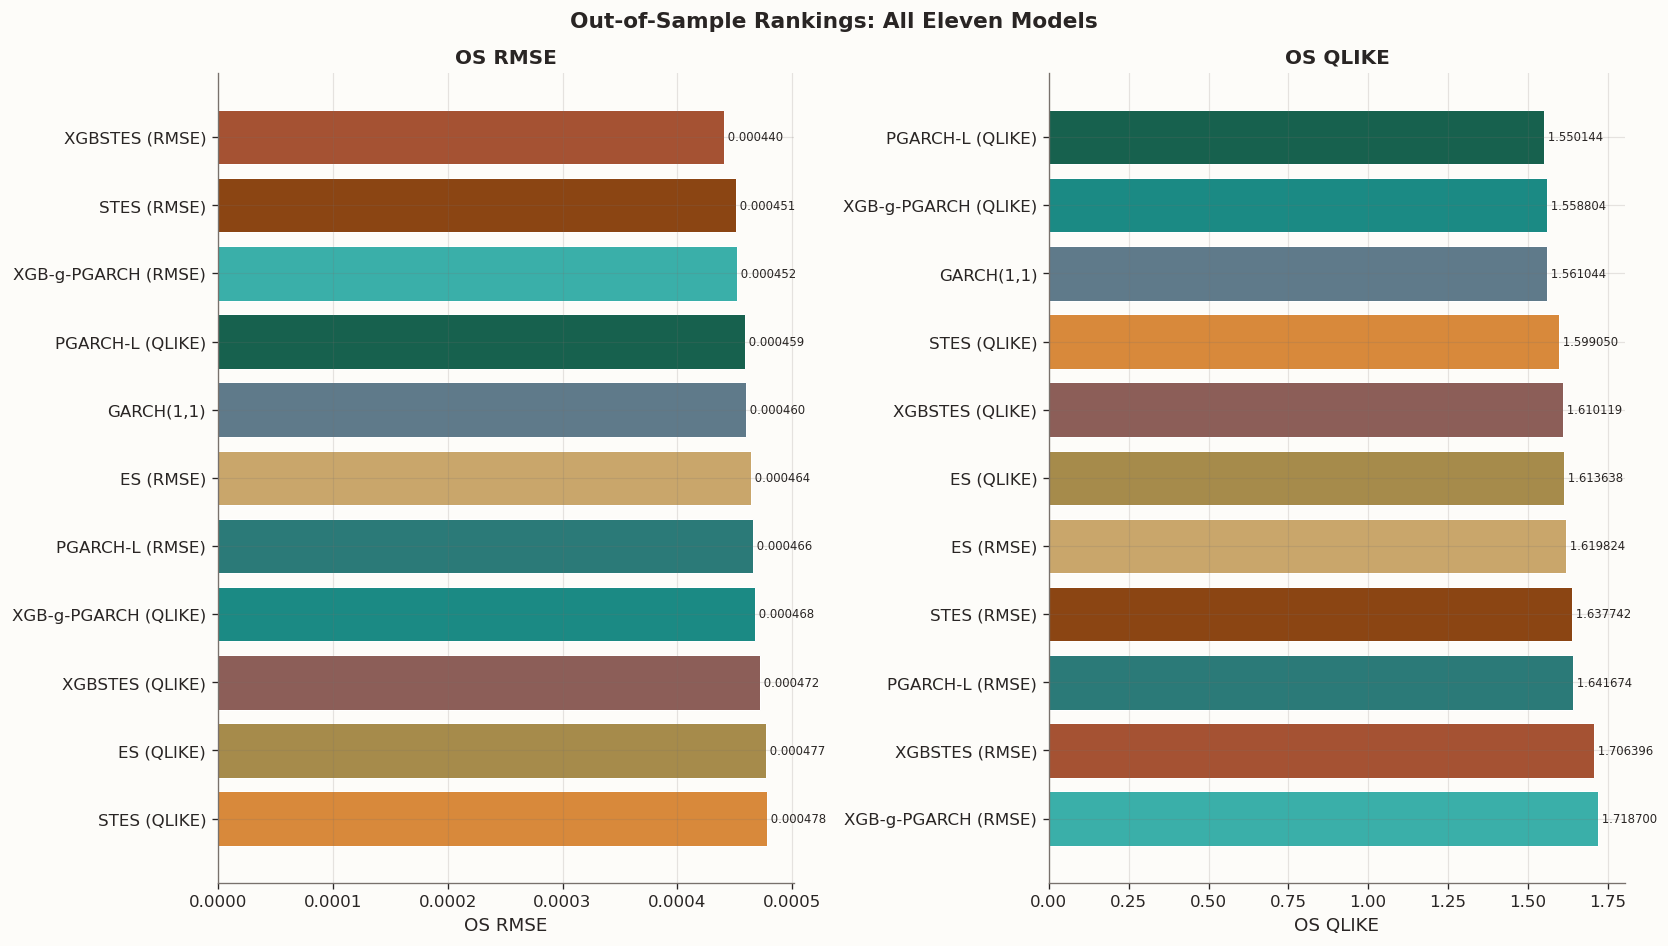

In [6]:
#| label: ranking-chart
#| code-fold: true
#| code-summary: "Two-panel ranking chart: OS RMSE vs OS QLIKE"

# Color mapping: PGARCH family gets a distinct blue-green palette
_palette = {
    "GARCH(1,1)":           "#5F7A8A",
    "ES (RMSE)":            "#C9A66B",
    "ES (QLIKE)":           "#A68B4B",
    "STES (RMSE)":          BLOG_PALETTE[0],
    "STES (QLIKE)":         "#D8893B",
    "XGBSTES (RMSE)":       BLOG_PALETTE[1],
    "XGBSTES (QLIKE)":      "#8C5E58",
    "PGARCH-L (RMSE)":      "#2B7A78",
    "PGARCH-L (QLIKE)":     "#17614E",
    "XGB-g-PGARCH (RMSE)":  "#3AAFA9",
    "XGB-g-PGARCH (QLIKE)": "#1B8A84",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, metric in zip(axes, ["OS RMSE", "OS QLIKE"]):
    chart_df = comparison_table.sort_values(metric, ascending=True).reset_index(drop=True)
    colors = [_palette.get(m, "#999999") for m in chart_df["Model"]]
    bars = ax.barh(chart_df["Model"], chart_df[metric], color=colors, edgecolor="white", linewidth=0.6)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    for bar, val in zip(bars, chart_df[metric]):
        ax.text(val, bar.get_y() + bar.get_height() / 2, f" {val:.6f}", va="center", fontsize=7)

fig.suptitle("Out-of-Sample Rankings: All Eleven Models", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Analysis

The benchmark table and ranking chart shows the following:

**PGARCH-L (QLIKE) takes the top QLIKE spot.** With an OS QLIKE of 1.550, it edges out GARCH(1,1) (1.561) — the model that dominated every STES variant in [Part 4](../volatility-forecasts-4/). It also ranks 4th in RMSE (0.000459), making it the first model in the series to be competitive on *both* metrics simultaneously. This confirms the structural hypothesis: preserving the three-channel decomposition ($\mu$, $\phi$, $g$) while adding predictor-driven flexibility is what it takes to match or beat GARCH under QLIKE.

**XGB-g-PGARCH (RMSE) is the 3rd-best RMSE model** (0.000452), behind only XGBSTES (RMSE) and STES (RMSE). The nonlinear boosting in the $g$-channel picks up level-sensitive signal that the linear model misses. However, the same model ranks dead last in QLIKE (1.719) — worse even than XGBSTES (RMSE). The boosted gate's flexibility, when trained under RMSE, drives the variance forecast in directions that QLIKE punishes.

**XGB-g-PGARCH (QLIKE) lands between the linear extremes.** At QLIKE rank 2 (1.559) it closes most of the gap to GARCH but falls behind PGARCH-L (QLIKE). Its RMSE is somewhat worse (rank 8, 0.000468). The result suggests that boosting the $g$-channel under QLIKE adds noise relative to the linear baseline — the current three-feature predictor space does not contain enough nonlinear signal to justify the additional flexibility.

**RMSE-trained PGARCH-L misses on QLIKE** (1.642, rank 9), echoing the [Part 4](../volatility-forecasts-4/) finding that even the right model structure cannot overcome a misaligned training loss.

We now formalize these observations with head-to-head comparisons, Diebold-Mariano tests, and Mincer-Zarnowitz calibration regressions.

In [7]:
#| label: head-to-head-table
#| tbl-cap: "Head-to-head: RMSE-trained vs QLIKE-trained within each PGARCH family, and cross-family comparisons"

# ── Within-family: PGARCH-L and XGB-g-PGARCH ───────────────────────────
head_to_head = pd.DataFrame({
    "Family": ["PGARCH-L", "XGB-g-PGARCH"],
    "OS RMSE (RMSE)": [
        rmse(actual_os, pgarch_l_rmse_os),
        rmse(actual_os, xgb_pgarch_rmse_os),
    ],
    "OS RMSE (QLIKE)": [
        rmse(actual_os, pgarch_l_qlike_os),
        rmse(actual_os, xgb_pgarch_qlike_os),
    ],
    "Δ RMSE": [
        rmse(actual_os, pgarch_l_qlike_os) - rmse(actual_os, pgarch_l_rmse_os),
        rmse(actual_os, xgb_pgarch_qlike_os) - rmse(actual_os, xgb_pgarch_rmse_os),
    ],
    "OS QLIKE (RMSE)": [
        qlike(actual_os, pgarch_l_rmse_os),
        qlike(actual_os, xgb_pgarch_rmse_os),
    ],
    "OS QLIKE (QLIKE)": [
        qlike(actual_os, pgarch_l_qlike_os),
        qlike(actual_os, xgb_pgarch_qlike_os),
    ],
    "Δ QLIKE": [
        qlike(actual_os, pgarch_l_qlike_os) - qlike(actual_os, pgarch_l_rmse_os),
        qlike(actual_os, xgb_pgarch_qlike_os) - qlike(actual_os, xgb_pgarch_rmse_os),
    ],
})

print("Head-to-head: RMSE-trained vs QLIKE-trained within each PGARCH family:")
display(style_results_table(head_to_head, precision=6, index_col="Family"))

# ── Full 11-model ranking table ─────────────────────────────────────────
rank_table = comparison_table[["Model", "OS RMSE", "OS QLIKE"]].copy()
rank_table["RMSE Rank"] = rank_table["OS RMSE"].rank(method="dense").astype(int)
rank_table["QLIKE Rank"] = rank_table["OS QLIKE"].rank(method="dense").astype(int)
rank_table = rank_table.sort_values(["RMSE Rank", "QLIKE Rank"]).reset_index(drop=True)

print("\nOut-of-sample ranking under both loss functions:")
display(style_results_table(rank_table, precision=6, index_col="Model"))

Head-to-head: RMSE-trained vs QLIKE-trained within each PGARCH family:


,OS RMSE (RMSE),OS RMSE (QLIKE),Δ RMSE,OS QLIKE (RMSE),OS QLIKE (QLIKE),Δ QLIKE
Family,,,,,,
PGARCH-L,0.000466,0.000459,-0.000007,1.641674,1.550144,-0.091530
XGB-g-PGARCH,0.000452,0.000468,0.000016,1.718700,1.558804,-0.159896



Out-of-sample ranking under both loss functions:


,OS RMSE,OS QLIKE,RMSE Rank,QLIKE Rank
Model,,,,
XGBSTES (RMSE),0.000440,1.706396,1,10
STES (RMSE),0.000451,1.637742,2,8
XGB-g-PGARCH (RMSE),0.000452,1.718700,3,11
PGARCH-L (QLIKE),0.000459,1.550144,4,1
"GARCH(1,1)",0.000460,1.561044,5,3
ES (RMSE),0.000464,1.619824,6,7
PGARCH-L (RMSE),0.000466,1.641674,7,9
XGB-g-PGARCH (QLIKE),0.000468,1.558804,8,2
XGBSTES (QLIKE),0.000472,1.610119,9,5


## Formal Comparison and Calibration

Point metrics and rankings are informative, but we need to test whether the differences are statistically meaningful. As in [Part 4](../volatility-forecasts-4/), we use two complementary diagnostics ([background](../forecast-comparison/)):

1. **Diebold-Mariano tests** on squared-error and QLIKE loss differentials. A negative DM statistic favors the first-named model.
2. **Mincer-Zarnowitz regressions** on the variance scale. A slope $\beta \approx 1$ indicates well-calibrated forecasts.

The key pairwise comparisons are: PGARCH-L vs GARCH (does the linear structural model match the benchmark?), XGB-g-PGARCH vs GARCH (does boosting improve on it?), XGB-g-PGARCH vs XGBSTES (does the PGARCH model family beat the STES model family?), and XGB-g-PGARCH vs PGARCH-L (does nonlinear flexibility in $g_t$ help or hurt?).

In [8]:
#| label: dm-mz-tests
#| code-fold: true
#| code-summary: "Diebold-Mariano tests and Mincer-Zarnowitz regressions"


def _sq_loss(y, yhat):
    return (np.asarray(y) - np.asarray(yhat)) ** 2


def _qlike_loss(y, yhat, eps=1e-8):
    y, yhat = np.asarray(y, dtype=float), np.clip(np.asarray(yhat, dtype=float), eps, None)
    ratio = np.clip(y, eps, None) / yhat
    return ratio - np.log(ratio) - 1.0


# ── Key pairwise DM comparisons ────────────────────────────────────────
dm_pairs = [
    # PGARCH-L vs GARCH
    ("PGARCH-L (RMSE) vs GARCH",       pgarch_l_rmse_os,       garch_pred_os),
    ("PGARCH-L (QLIKE) vs GARCH",      pgarch_l_qlike_os,      garch_pred_os),
    # XGB-g-PGARCH vs GARCH
    ("XGB-g-PGARCH (RMSE) vs GARCH",   xgb_pgarch_rmse_os,     garch_pred_os),
    ("XGB-g-PGARCH (QLIKE) vs GARCH",  xgb_pgarch_qlike_os,    garch_pred_os),
    # XGB-g-PGARCH vs XGBSTES (same family comparison)
    ("XGB-g-PGARCH (RMSE) vs XGBSTES (RMSE)",   xgb_pgarch_rmse_os,  xgbstes_pred_os),
    ("XGB-g-PGARCH (QLIKE) vs XGBSTES (QLIKE)",  xgb_pgarch_qlike_os, xgb_qlike_pred_os),
    # XGB-g-PGARCH vs PGARCH-L (boosting benefit)
    ("XGB-g-PGARCH (RMSE) vs PGARCH-L (RMSE)",   xgb_pgarch_rmse_os,  pgarch_l_rmse_os),
    ("XGB-g-PGARCH (QLIKE) vs PGARCH-L (QLIKE)",  xgb_pgarch_qlike_os, pgarch_l_qlike_os),
]

dm_rows = []
for label, pred_a, pred_b in dm_pairs:
    res_sq = diebold_mariano(_sq_loss(actual_os, pred_a), _sq_loss(actual_os, pred_b), h=1)
    res_ql = diebold_mariano(_qlike_loss(actual_os, pred_a), _qlike_loss(actual_os, pred_b), h=1)
    dm_rows.append({
        "Comparison": label,
        "DM (SqErr)": res_sq["dm_stat"], "p (SqErr)": res_sq["p_value"],
        "DM (QLIKE)": res_ql["dm_stat"], "p (QLIKE)": res_ql["p_value"],
    })

dm_table = pd.DataFrame(dm_rows)
print("Diebold-Mariano tests (negative DM favors first-named model):")
display(style_results_table(dm_table, precision=4, index_col="Comparison"))

# ── Mincer-Zarnowitz regressions ────────────────────────────────────────
mz_models = [
    ("GARCH(1,1)",           garch_pred_os),
    ("ES (RMSE)",            es_pred_os),
    ("STES (RMSE)",          stes_pred_os),
    ("XGBSTES (RMSE)",       xgbstes_pred_os),
    ("XGBSTES (QLIKE)",      xgb_qlike_pred_os),
    ("PGARCH-L (RMSE)",      pgarch_l_rmse_os),
    ("PGARCH-L (QLIKE)",     pgarch_l_qlike_os),
    ("XGB-g-PGARCH (RMSE)",  xgb_pgarch_rmse_os),
    ("XGB-g-PGARCH (QLIKE)", xgb_pgarch_qlike_os),
]

mz_rows = []
for label, pred in mz_models:
    mz = mincer_zarnowitz(actual_os, pred)
    mz_rows.append({
        "Model": label,
        "const": mz["params"].get("const", np.nan),
        "beta": mz["params"].get("beta", np.nan),
        "R2": mz["r2"],
    })

mz_table = pd.DataFrame(mz_rows)
print("\nMincer-Zarnowitz calibration regressions:")
display(style_results_table(mz_table, precision=4, index_col="Model"))

Diebold-Mariano tests (negative DM favors first-named model):


,DM (SqErr),p (SqErr),DM (QLIKE),p (QLIKE)
Comparison,,,,
PGARCH-L (RMSE) vs GARCH,1.3016,0.1932,4.7745,0.0000
PGARCH-L (QLIKE) vs GARCH,-0.0735,0.9414,-0.4210,0.6738
XGB-g-PGARCH (RMSE) vs GARCH,-0.6818,0.4955,3.2143,0.0013
XGB-g-PGARCH (QLIKE) vs GARCH,0.5035,0.6147,-0.0917,0.9270
XGB-g-PGARCH (RMSE) vs XGBSTES (RMSE),0.8876,0.3749,0.8201,0.4123
XGB-g-PGARCH (QLIKE) vs XGBSTES (QLIKE),-0.1289,0.8975,-1.2912,0.1968
XGB-g-PGARCH (RMSE) vs PGARCH-L (RMSE),-1.1962,0.2317,1.2643,0.2063
XGB-g-PGARCH (QLIKE) vs PGARCH-L (QLIKE),1.4877,0.1370,2.1293,0.0333



Mincer-Zarnowitz calibration regressions:


,const,beta,R2
Model,,,
"GARCH(1,1)",-0.0000,1.0190,0.2652
ES (RMSE),0.0000,0.8843,0.2564
STES (RMSE),0.0000,1.0122,0.2930
XGBSTES (RMSE),0.0000,1.0725,0.3275
XGBSTES (QLIKE),0.0000,0.7272,0.2635
PGARCH-L (RMSE),-0.0000,1.0262,0.2466
PGARCH-L (QLIKE),-0.0000,1.2821,0.2817
XGB-g-PGARCH (RMSE),0.0000,1.0690,0.2910
XGB-g-PGARCH (QLIKE),-0.0000,1.1459,0.2431


The DM tests organize the eleven models into four stories.

1. **PGARCH-L (QLIKE) vs GARCH — statistically indistinguishable.**
   Under QLIKE loss, DM = −0.42 (p = 0.67); under squared error, DM = −0.07 (p = 0.94). The point estimates favor PGARCH-L on both metrics, but the improvement is too small to reject equal predictive ability. This is still a meaningful result though: PGARCH-L *matches* GARCH under QLIKE — something no STES variant accomplished in Part 4. When trained under RMSE instead, PGARCH-L significantly underperforms GARCH on QLIKE (DM = 4.77, p < 0.001), confirming that the training loss must align with the evaluation criterion.

2. **XGB-g-PGARCH (QLIKE) vs GARCH — also indistinguishable.**
   DM = −0.09 (p = 0.93) under QLIKE. The boosted model matches GARCH but does not improve on it. However, XGB-g-PGARCH (RMSE) tells a different story: despite ranking 3rd in RMSE, it significantly underperforms GARCH on QLIKE (DM = 3.21, p = 0.001). The boosted $g$-channel, when optimized for squared error, overshoots on the episodes that QLIKE penalizes most.

3. **XGB-g-PGARCH vs PGARCH-L — boosting hurts under QLIKE.**
   XGB-g-PGARCH (QLIKE) vs PGARCH-L (QLIKE) yields DM = 2.13 (p = 0.033) under QLIKE loss — the *linear* model significantly outperforms the *boosted* model. Under squared error, DM = 1.49 (p = 0.14) also favors PGARCH-L directionally. With only three return-based features, the nonlinear flexibility in the boosted $g$-channel does not find useful signal; it adds estimation noise that degrades QLIKE performance. This result underscores that model complexity must be justified by feature richness.

4. **PGARCH vs STES/XGBSTES.**
   XGB-g-PGARCH (RMSE) vs XGBSTES (RMSE): DM = 0.82 (p = 0.41) under QLIKE. XGBSTES still has the lower mean QLIKE on this split, but once the RMSE baselines are refit locally the difference is no longer statistically significant. XGB-g-PGARCH (QLIKE) vs XGBSTES (QLIKE): DM = −1.29 (p = 0.20) — the PGARCH model family shows a directional QLIKE advantage but not significant.

**MZ calibration** reveals a trade-off between QLIKE score and proportional calibration. GARCH (β = 1.02) and PGARCH-L (RMSE) (β = 1.03) are the best-calibrated models. PGARCH-L (QLIKE) overshoots to β = 1.28, while XGB-g-PGARCH (QLIKE) sits at β = 1.15 — better calibrated than PGARCH-L (QLIKE) but with a worse QLIKE score. The boosted model's additional flexibility pulls calibration back toward one at the cost of QLIKE optimality. XGBSTES (RMSE) retains the highest R² (0.33), while the PGARCH family ranges from 0.24 to 0.29.

## Structural Parameter Dynamics

One advantage of the PGARCH decomposition over STES is interpretability. Because PGARCH exposes $\mu_t$, $\phi_t$, and $g_t$ as separate time-varying quantities, we can inspect how each structural role evolves over the out-of-sample period. STES provides only a single gate $\alpha_t$, which conflates all three roles.

The figure below plots the three channels from PGARCH-L (QLIKE) over the test period. We expect $\mu_t$ to track long-run variance regimes, $\phi_t$ to remain high (reflecting the well-known persistence of equity volatility), and $g_t$ to spike after large shocks — the same reaction pattern that STES captures, but now isolated from the persistence and level channels.

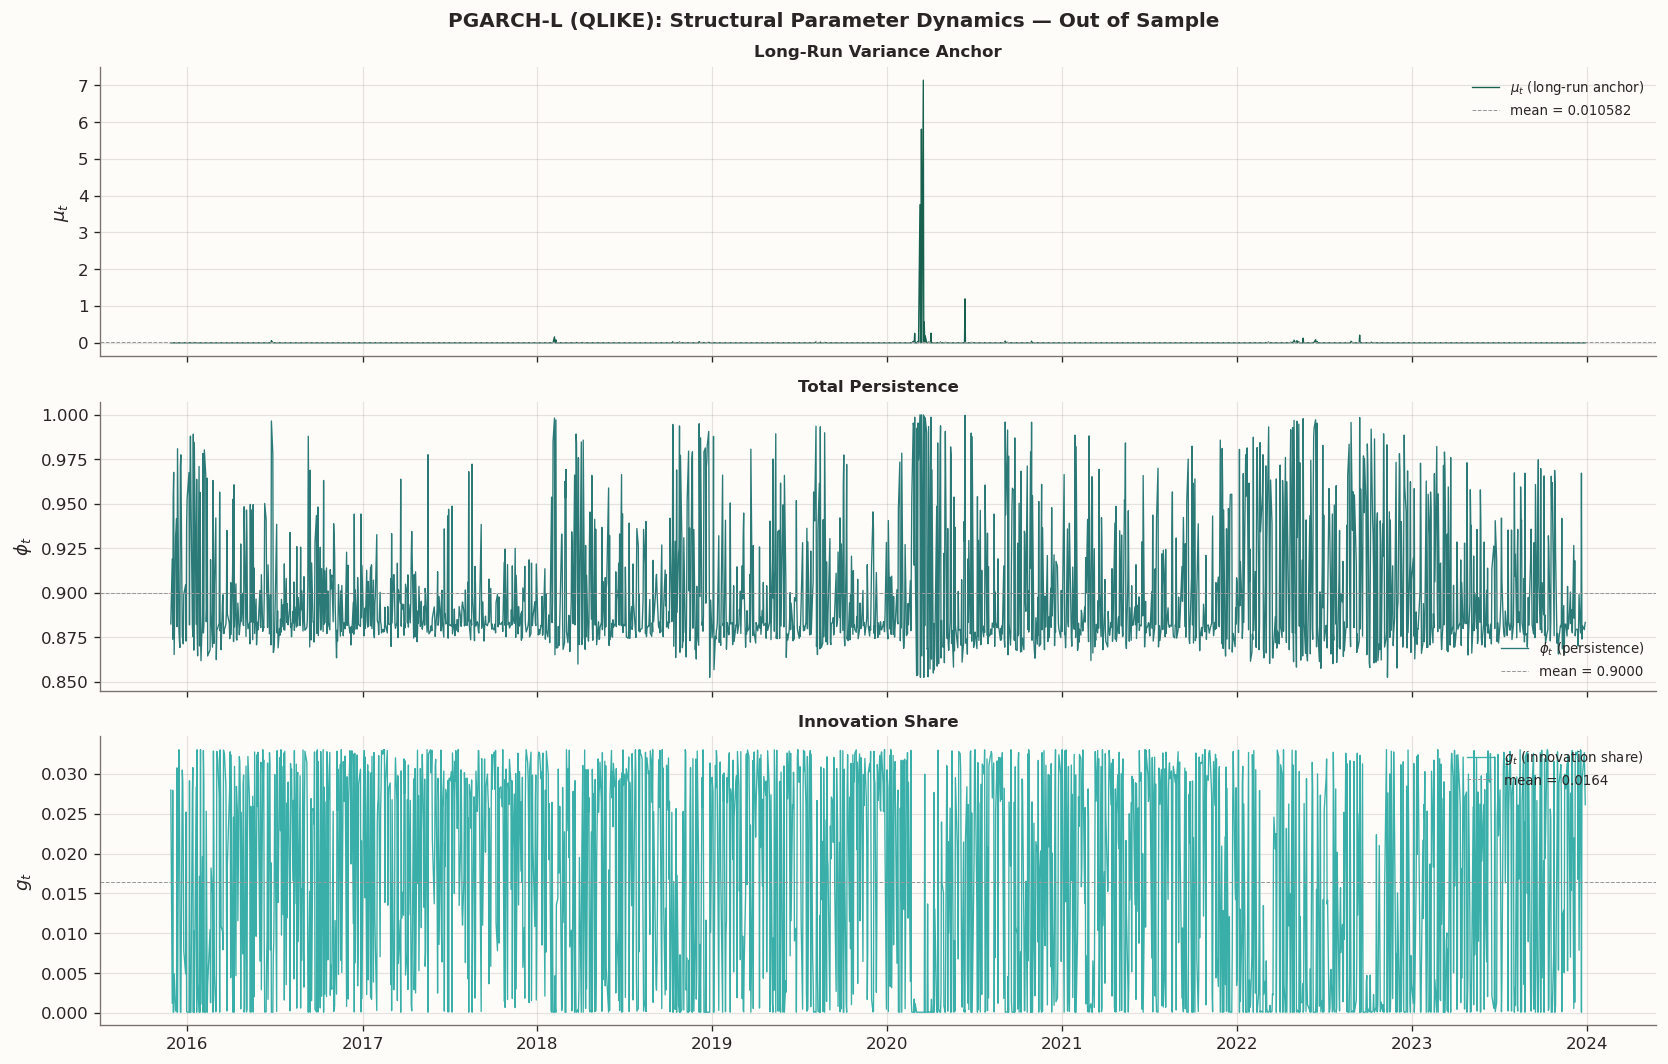

In [9]:
#| code-fold: true
#| code-summary: "Time-varying structural parameters: μ_t, φ_t, g_t over the test period"

# Extract PGARCH-L (QLIKE) structural components for the OS period
comps_os = pgarch_l_qlike.predict_components(X_pgarch_te.values)
mu_os = comps_os["mu"]
phi_os = comps_os["phi"]
g_os = comps_os["g"]
dates_os = X_te.index

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Panel 1: long-run anchor μ_t
axes[0].plot(dates_os, mu_os, color="#17614E", linewidth=0.8, label=r"$\mu_t$ (long-run anchor)")
axes[0].axhline(np.mean(mu_os), color="#999999", linestyle="--", linewidth=0.6, label=f"mean = {np.mean(mu_os):.6f}")
axes[0].set_ylabel(r"$\mu_t$")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Long-Run Variance Anchor", fontsize=10, fontweight="bold")

# Panel 2: total persistence φ_t
axes[1].plot(dates_os, phi_os, color="#2B7A78", linewidth=0.8, label=r"$\phi_t$ (persistence)")
axes[1].axhline(np.mean(phi_os), color="#999999", linestyle="--", linewidth=0.6, label=f"mean = {np.mean(phi_os):.4f}")
axes[1].set_ylabel(r"$\phi_t$")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].set_title("Total Persistence", fontsize=10, fontweight="bold")

# Panel 3: innovation share g_t
axes[2].plot(dates_os, g_os, color="#3AAFA9", linewidth=0.8, label=r"$g_t$ (innovation share)")
axes[2].axhline(np.mean(g_os), color="#999999", linestyle="--", linewidth=0.6, label=f"mean = {np.mean(g_os):.4f}")
axes[2].set_ylabel(r"$g_t$")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].set_title("Innovation Share", fontsize=10, fontweight="bold")

fig.suptitle("PGARCH-L (QLIKE): Structural Parameter Dynamics — Out of Sample", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

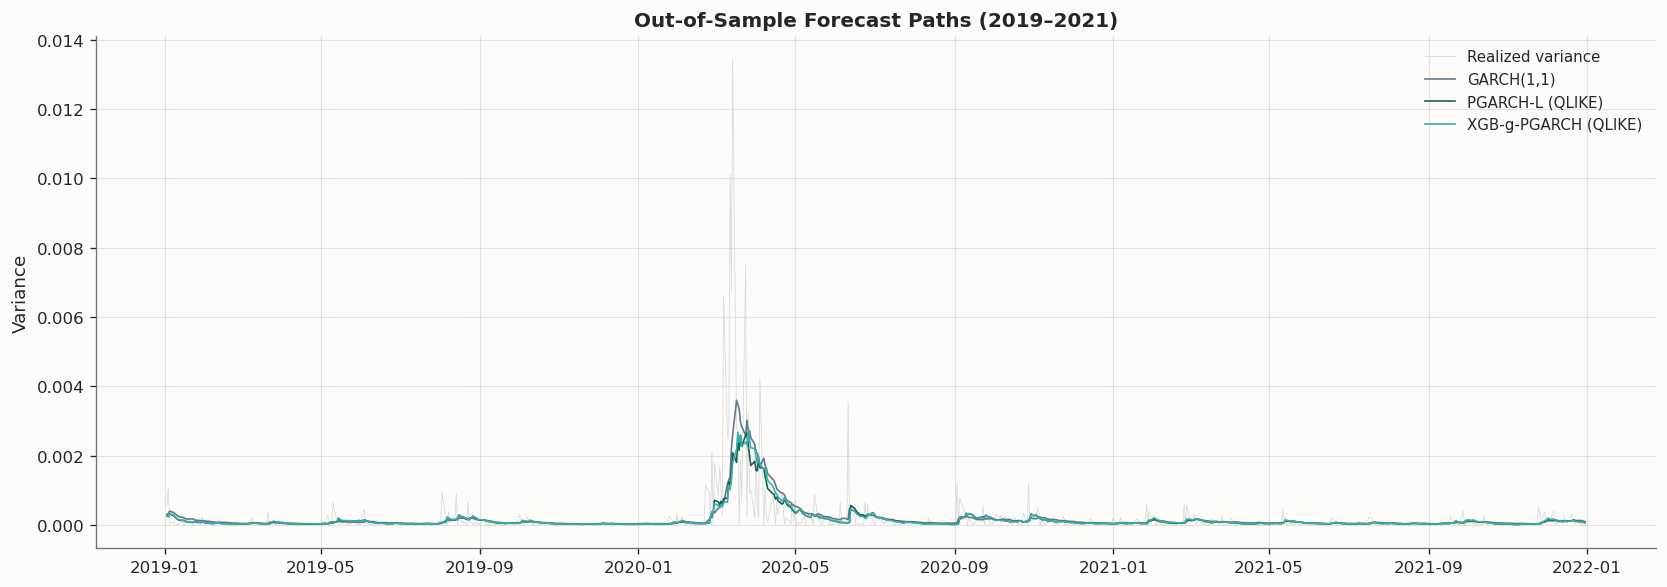

In [10]:
#| code-fold: true
#| code-summary: "Forecast paths: GARCH vs PGARCH-L vs XGB-g-PGARCH (2019–2021 window)"

# Focus on a window that includes the COVID volatility spike
window_start = pd.Timestamp("2019-01-01", tz="UTC")
window_end = pd.Timestamp("2021-12-31", tz="UTC")
mask = (dates_os >= window_start) & (dates_os <= window_end)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_os[mask], actual_os[mask], color="#CCCCCC", linewidth=0.5, alpha=0.7, label="Realized variance")
ax.plot(dates_os[mask], garch_pred_os[mask], color="#5F7A8A", linewidth=1.0, label="GARCH(1,1)")
ax.plot(dates_os[mask], pgarch_l_qlike_os[mask], color="#17614E", linewidth=1.0, label="PGARCH-L (QLIKE)")
ax.plot(dates_os[mask], xgb_pgarch_qlike_os[mask], color="#3AAFA9", linewidth=1.0, label="XGB-g-PGARCH (QLIKE)")

ax.set_ylabel("Variance")
ax.set_title("Out-of-Sample Forecast Paths (2019–2021)", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## Summary of Rankings

Across all eleven model variants, the ranking table reveals a clear separation by training objective. Under RMSE, the top three are XGBSTES (RMSE), STES (RMSE), and XGB-g-PGARCH (RMSE). Under QLIKE, the top three are PGARCH-L (QLIKE), XGB-g-PGARCH (QLIKE), and GARCH(1,1).

PGARCH-L (QLIKE) is the first model in the series to rank in the top four under *both* criteria (rank 4 in RMSE, rank 1 in QLIKE). In Part 4, GARCH was the sole dual-metric performer. This is achieved by combining the GARCH structure that QLIKE rewards with predictor-driven flexibility that keeps RMSE competitive.

The boosted XGB-g-PGARCH variant shows a different pattern: strong in RMSE when RMSE-trained (rank 3), strong in QLIKE when QLIKE-trained (rank 2), but with sharper trade-offs between the two metrics. On this feature set, the linear PGARCH-L is the more robust choice.

## Conclusion

In this post we introduced PGARCH — a model family that generalizes GARCH(1,1) by making its structural parameters dependent on exogenous variables — and benchmarked two members against the seven models from Part 4. Three findings stand out.

1. The structural decomposition reduces QLIKE loss. PGARCH-L (QLIKE) achieves the best out-of-sample QLIKE score (1.550) across all eleven model variants, edging out GARCH(1,1) (1.561) while remaining competitive in RMSE (rank 4). No STES variant accomplished this in Part 4. The three-channel decomposition — separate $\mu$, $\phi$, $g$ — is the structural feature that QLIKE rewards, and PGARCH preserves it while adding predictor-driven flexibility. Formally, the DM test shows the improvement over GARCH is directional but not statistically significant (p = 0.67), placing PGARCH-L on equal footing with GARCH rather than clearly surpassing it.

2. Boosting the $g$-channel alone creates on three features creates noisy results. XGB-g-PGARCH shows that nonlinear flexibility in the innovation-share channel can help (RMSE rank 3 under RMSE training) or hurt (significantly worse than PGARCH-L under QLIKE, DM = 2.13, p = 0.033). With only three return-based features, the boosted gate does not find enough nonlinear signal to justify its additional complexity under QLIKE — it adds estimation noise.

3. Training loss still dominates model structure. PGARCH-L (RMSE) scores 1.642 under QLIKE and is significantly worse than GARCH (DM = 4.77, p < 0.001). XGB-g-PGARCH (RMSE) is even worse at 1.719, last among all eleven models. The same structural decomposition that leads the QLIKE rankings under QLIKE training falls to ranks 9 and 11 under RMSE training.

### What's next

The finding that boosting hurts on a sparse feature set points directly to the next step: the feature set may be the binding constraint. In the next post we will explore the following directions:

1. **Feature expansion** — adding trailing realized-variance windows, calendar indicators, and economic variables to the predictor set. With a richer feature space, the nonlinear capacity of XGB-g-PGARCH should become an advantage rather than a liability.
2. **Multi-channel boosting** — extending the XGBoost objective to jointly learn $\mu_t$ and $g_t$ (or all three channels), allowing the long-run anchor to respond to macroeconomic regimes.
3. **Rolling evaluation** — replacing the fixed split with expanding-window or rolling-origin evaluation to produce time-indexed DM statistics and assess forecast stability across market regimes.

## Appendix: PGARCH Derivative Details

This appendix collects the full derivative formulas used to train the models in this post.

### Loss functions

We consider two training losses over the effective sample $t = 1, \ldots, T-1$ (excluding the warm-start $h_0$), with $N = T-1$:

**MSE:**
$$
L_{\text{MSE}} = \frac{1}{N}\sum_{t=1}^{T-1}(y_t - h_t)^2, \qquad u_t = \frac{2(h_t - y_t)}{N}, \qquad v_t = \frac{2}{N}
$$

**QLIKE:**
$$
L_{\text{QLIKE}} = \frac{1}{N}\sum_{t=1}^{T-1}\left(\log h_t + \frac{y_t}{h_t}\right), \qquad u_t = \frac{1}{N}\left(\frac{1}{h_t} - \frac{y_t}{h_t^2}\right), \qquad v_t = \frac{1}{N}\left(-\frac{1}{h_t^2} + \frac{2y_t}{h_t^3}\right)
$$

### Jacobian recursion (Linear PGARCH)

Let $\theta = [w_\mu, w_\phi, w_g]$ and $\tilde{x}_{t-1} = [1, x_{t-1}]$. Define block-embedded vectors $d_t^\mu$, $d_t^\phi$, $d_t^g$ that place $\tilde{x}_{t-1}$ in the appropriate block of $\theta$ and zeros elsewhere.

The component Jacobians use the link derivatives:

$$
J_t^\mu = \sigma(a_t) d_t^\mu, \qquad
J_t^\phi = (\phi_{\max} - \phi_{\min}) s_b(1-s_b) d_t^\phi, \qquad
J_t^g = (g_{\max} - g_{\min}) s_c(1-s_c) d_t^g
$$

The intermediate quantity $q_t = g_t y_{t-1} + (1-g_t)h_{t-1}$ has Jacobian

$$
J_t^q = (1 - g_t) J_{t-1} + (y_{t-1} - h_{t-1}) J_t^g
$$

The state Jacobian follows from $h_t = (1-\phi_t)\mu_t + \phi_t q_t$:

$$
J_t = (1-\phi_t) J_t^\mu + (q_t - \mu_t) J_t^\phi + \phi_t J_t^q, \qquad J_0 = 0
$$

### Hessian recursion (Linear PGARCH)

The link Hessians are rank-one matrices:

$$
H_t^\mu = s_a(1-s_a) d_t^\mu (d_t^\mu)^\top, \qquad
H_t^\phi = (\phi_{\max}-\phi_{\min}) s_b(1-s_b)(1-2s_b) d_t^\phi (d_t^\phi)^\top
$$

and similarly for $H_t^g$. The Hessian recursions are:

$$
H_t^q = (1-g_t) H_{t-1} + (y_{t-1}-h_{t-1}) H_t^g - J_t^g J_{t-1}^\top - J_{t-1}(J_t^g)^\top
$$

$$
H_t = (1-\phi_t) H_t^\mu + (q_t-\mu_t) H_t^\phi + \phi_t H_t^q + J_t^\phi(J_t^q - J_t^\mu)^\top + (J_t^q - J_t^\mu)(J_t^\phi)^\top, \qquad H_0 = 0
$$

### Gradient and Hessian of the training loss

$$
\nabla_\theta L = \sum_{t=1}^{T-1} u_t J_t, \qquad
\nabla_\theta^2 L = \sum_{t=1}^{T-1}\left(v_t J_t J_t^\top + u_t H_t\right)
$$

### XGB-g-PGARCH adjoint gradient

With $\mu_t$, $\phi_t$ fixed and only $c_t$ (the raw score for $g_t$) variable:

- **Local impulse:** $\delta_s = \phi_s(y_s - h_s) C_s$ where $C_s = (g_{\max}-g_{\min}) \sigma(c_s)(1-\sigma(c_s))$.
- **State propagation:** $\rho_s = \phi_s(1-g_s)$.
- **Adjoint:** $\lambda_{T-1} = u_{T-1}$; $\lambda_t = u_t + \rho_t \lambda_{t+1}$ for $t = T-2, \ldots, 0$.
- **Row gradient:** $G_s = \lambda_{s+1}\,\delta_s$ for $s = 0, \ldots, T-2$; $G_{T-1} = 0$.

### XGB-g-PGARCH Hessian approximation

**MSE (Gauss-Newton):**
$$
H_s \approx \sum_{t=s+1}^{T-1} \frac{2}{N}\left(\frac{\partial h_t}{\partial c_s}\right)^2
$$

**QLIKE (Fisher-style):** replace $2/N$ with $w_t = \operatorname{clip}(1/(N h_t^2), \varepsilon, w_{\max})$.

Both are computed efficiently via a backward accumulation:

$$
F_{T-1} = w_{T-1}, \qquad F_t = w_t + \rho_t^2 F_{t+1}, \qquad H_s = \delta_s^2 F_{s+1}
$$